# Notebook 3: Probability Refresher and Descriptive Statistics

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 3, Probability and Descriptive Statistics**. Last
week every signal was one we had generated ourselves, so we knew the right answer in advance.
This week we open a real dataset for the first time, and with it comes the problem that runs
through the rest of the course: **the data you have is one sample out of many you could have
had**, and every number you compute from it would have come out differently if the experiment
had been run again.

That idea, the **sampling distribution**, is the hinge between describing data (this week) and
testing hypotheses about it (next week).

### By the end of this notebook you will be able to:
- Draw random numbers reproducibly with a **seeded generator**, and explain why the seed matters.
- Recognise four distributions that keep appearing in neuroscience, and say what each one models.
- Load a real behavioural dataset with **pandas** and summarise it with `describe` and `groupby`.
- Look at a distribution four ways (**histogram, KDE, box plot, violin plot**) and say what each
  view hides.
- Compute **centre and spread** by hand and with pandas, and choose between mean/SD and
  median/IQR when the data are skewed.
- Build a **sampling distribution** by simulation, and use it to see the **Law of Large Numbers**
  and the **Central Limit Theorem** happen.
- Tell **SD apart from SEM**: how much the data vary, versus how uncertain your estimate is.
- Clean a messy variable, and describe a real group difference honestly, without a statistical
  test.

### Table of contents
0. [Setting up and meeting the data](#section-0)
1. [Samples, distributions and summaries](#section-1)
   - 1.1 [Population, sample, statistic](#section-1-1)
   - 1.2 [Random numbers and the seed](#section-1-2)
   - 1.3 [Four distributions worth knowing](#section-1-3)
   - 1.4 [Four views of one distribution](#section-1-4)
   - 1.5 [Centre and spread](#section-1-5)
2. [From a sample to an estimate](#section-2)
   - 2.1 [Expectation and variance](#section-2-1)
   - 2.2 [The sampling distribution of the mean](#section-2-2)
   - 2.3 [The Law of Large Numbers](#section-2-3)
   - 2.4 [The Central Limit Theorem](#section-2-4)
   - 2.5 [SD versus SEM](#section-2-5)
3. [Describing the real data](#section-3)
   - 3.1 [Reaction times by cohort](#section-3-1)
   - 3.2 [Learning curves](#section-3-2)
   - 3.3 [Psychometric curves](#section-3-3)
   - 3.4 [Re-running the experiment: sessions as samples](#section-3-4)
   - 3.5 [A group difference, described](#section-3-5)
4. [What comes next](#section-4)

> **How to read this notebook.** Markdown cells explain the concept, code cells implement it.
> **`▶ Task`** boxes are short exercises, tagged by difficulty:
>
> - **⭐** essential: run it, understand it, change it slightly.
> - **⭐⭐** intermediate: complete the missing lines or write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller analysis yourself.
>
> If you use AI help, treat it as a tutor and not a substitute: you should be able to read every
> line and say what it does.

<a id="section-0"></a>
## 0. Setting up and meeting the data

Same environment as last week (`qmn`), plus two new libraries:

- **`pandas`** (as `pd`), for tables. A `DataFrame` is a spreadsheet you can compute with:
  named columns, mixed types, and one row per observation.
- **`seaborn`** (as `sns`), a thin layer on top of matplotlib that draws statistical plots
  (violins, KDEs) in one line instead of ten.

### The experiment

The data come from the **International Brain Laboratory** (IBL), a collaboration that ran the
same standardised behavioural task in labs across the world. A head-fixed mouse sits with its
front paws on a small wheel, facing a screen. On each trial a striped patch (a **Gabor grating**)
appears on the left or the right, and the mouse has to turn the wheel to bring it to the centre.
Correct turns earn a drop of water; wrong ones give a noise burst and a time-out.

The difficulty knob is **contrast**. At full contrast the patch is obvious; at zero contrast
there is nothing to see and the mouse can only guess. The dataset stores this as
`signed_contrast`, where the **sign** carries the side (positive = right, negative = left) and
the **magnitude** carries the difficulty.

### The animals

Thirty mice, in three groups of ten:

| Cohort | What it is |
|---|---|
| `CSHL-WT` | wild-type mice, Churchland lab, Cold Spring Harbor |
| `NYU-WT` | wild-type mice, Angelaki lab, New York University |
| `CSP-ASD` | mice carrying the **Cntnap2** mutation, a mouse model of autism, Angelaki lab |

Two comparisons are built into that design, and we will come back to them for the rest of the
course: wild-type against the autism model **within the same lab** (`NYU-WT` vs `CSP-ASD`), and
the same genotype **across two labs** (`CSHL-WT` vs `NYU-WT`).

Every mouse appears in two phases: `training`, its whole learning history on the basic task, and
`trained`, its last eight sessions on the full task.

**Full column documentation is in `data/ibl_2afc_datadictionary.md`.** Read it once: knowing what
is in your columns is not optional, and it is where you will find out which columns are raw and
which are derived.

In [ ]:
# DRAFT: delete this cell when the notebook is promoted to notebooks/
# While the draft lives in notebooks/drafts/ this points ROOT at notebooks/.
# After promotion, replace the body with: ROOT = Path(".")
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("draft mode, ROOT =", ROOT)

draft mode, ROOT = C:\Users\matteucc\Documents\QMN_course\notebooks


In [2]:
# --- Import the stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),
})

# One colour per cohort, used consistently in every figure below.
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}
COHORT_ORDER = ["CSHL-WT", "NYU-WT", "CSP-ASD"]

print(f"pandas  : {pd.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 3.0.2
seaborn : 0.13.2


In [3]:
# --- Load the trial table and the per-mouse table
# read_csv opens the .gz directly, no need to unzip anything first.
trials = pd.read_csv(ROOT / "data" / "ibl_2afc.csv.gz")
mice = pd.read_csv(ROOT / "data" / "ibl_2afc_subjects.csv")

# The cohort label is not stored in the file: we build it from lab and group.
mice["cohort"] = np.where(mice["lab"] == "churchlandlab", "CSHL-WT",
                  np.where(mice["group"] == "WT", "NYU-WT", "CSP-ASD"))

# Attach the per-mouse information to every trial (a "join" on subject_id).
trials = trials.merge(mice[["subject_id", "cohort", "group", "sex"]], on="subject_id")

print(f"{len(trials):,} trials from {trials.subject_id.nunique()} mice")
print("trials per phase :", trials.phase.value_counts().to_dict())
print("mice per cohort  :", mice.cohort.value_counts().to_dict())

694,182 trials from 30 mice
trials per phase : {'training': 508695, 'trained': 185487}
mice per cohort  : {'CSHL-WT': 10, 'CSP-ASD': 10, 'NYU-WT': 10}


In [4]:
# --- A first look at the table itself
print("columns:", list(trials.columns))
trials.head()

columns: ['trial_id', 'subject_id', 'phase', 'session', 'trial_in_session', 'signed_contrast', 'stimulus_side', 'response', 'correct', 'no_go', 'reaction_time_s', 'response_time_s', 'probability_left', 'reward_volume', 'stim_on_time_s', 'go_cue_time_s', 'first_movement_time_s', 'choice_time_s', 'feedback_time_s', 'cohort', 'group', 'sex']


,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,...,probability_left,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s,cohort,group,sex
0,0,CSHL051,training,1,1,0.5,right,1.0,1.0,False,...,0.5,3.0,3.3260,3.3438,NaN,17.9252,17.9252,CSHL-WT,WT,F
1,1,CSHL051,training,1,2,1.0,right,0.0,0.0,False,...,0.5,0.0,22.4601,22.4895,27.6399,28.6043,28.6373,CSHL-WT,WT,F
2,2,CSHL051,training,1,3,1.0,right,0.0,0.0,False,...,0.9,0.0,32.5464,32.5760,40.0259,40.3294,40.3646,CSHL-WT,WT,F
3,3,CSHL051,training,1,4,-1.0,left,1.0,0.0,False,...,0.8,0.0,43.8886,43.9192,43.9579,44.7219,44.7526,CSHL-WT,WT,F
4,4,CSHL051,training,1,5,-1.0,left,0.0,1.0,False,...,0.8,3.0,48.7176,48.7554,67.3039,67.4361,67.4361,CSHL-WT,WT,F


<a id="section-1"></a>
# Part 1. Samples, distributions and summaries

<a id="section-1-1"></a>
## 1.1 Population, sample, statistic

Three words that get used loosely in conversation and precisely in statistics:

- The **population**, or data-generating process, is the thing you actually care about: how this
  mouse behaves, in general. You never observe it.
- The **sample** is what you measured: these trials, on these days. It is finite and it is
  partly luck.
- A **statistic** is any number you compute from the sample: a mean, a median, a proportion
  correct. Because the sample was partly luck, the statistic is partly luck too.

The whole of the next two weeks follows from that last sentence. If you ran the experiment
again you would get a different sample and therefore a different number, and the spread of those
numbers across imaginary repetitions is called the **sampling distribution** of the statistic.
Part 2 builds one by brute force, which is the fastest way to stop finding the idea abstract.

<a id="section-1-2"></a>
## 1.2 Random numbers and the seed

Simulation is how we will study things that are hard to derive. For that we need random numbers,
and in NumPy the modern way is to create a **generator** with `np.random.default_rng(seed)`.

The **seed** is the starting point of the sequence. Given the same seed, the generator produces
exactly the same "random" numbers every time, which sounds like a contradiction but is what makes
simulation science rather than anecdote: anyone re-running your notebook gets your figures, not
figures that look vaguely similar. Change the seed and you get an independent repetition, which
is exactly what we want when we ask what would happen if the experiment were run again.

In [5]:
# --- The seed controls everything
rng_a = np.random.default_rng(42)
rng_b = np.random.default_rng(42)
rng_c = np.random.default_rng(7)

print("seed 42, first draw :", rng_a.normal(size=4).round(3))
print("seed 42, again      :", rng_b.normal(size=4).round(3))   # identical
print("seed  7, different  :", rng_c.normal(size=4).round(3))   # unrelated

seed 42, first draw : [ 0.305 -1.04   0.75   0.941]
seed 42, again      : [ 0.305 -1.04   0.75   0.941]
seed  7, different  : [ 0.001  0.299 -0.274 -0.891]


<a id="section-1-3"></a>
## 1.3 Four distributions worth knowing

A **random variable** maps an outcome to a number, and a **distribution** says how likely each
value is. Four cover most of what you will meet in a neuroscience methods course.

| Distribution | Models | Example here |
|---|---|---|
| **Bernoulli** | a single yes/no event | one trial: correct or not |
| **Binomial** | how many successes in n such events | correct trials in a session |
| **Poisson** | counts of rare events in a fixed window | spikes in a 100 ms bin |
| **Normal** | sums of many small independent effects | measurement noise, and see 2.4 |
| **Exponential** | waiting times between random events | intervals between spikes |

For **discrete** variables the distribution is a **probability mass function** (PMF): each
possible value has a probability, and they sum to one. For **continuous** variables it is a
**probability density function** (PDF), and a single exact value has probability zero: only
intervals have probabilities, given by the area under the curve. That is why the y axis of a
density plot is not a probability and can happily exceed one.

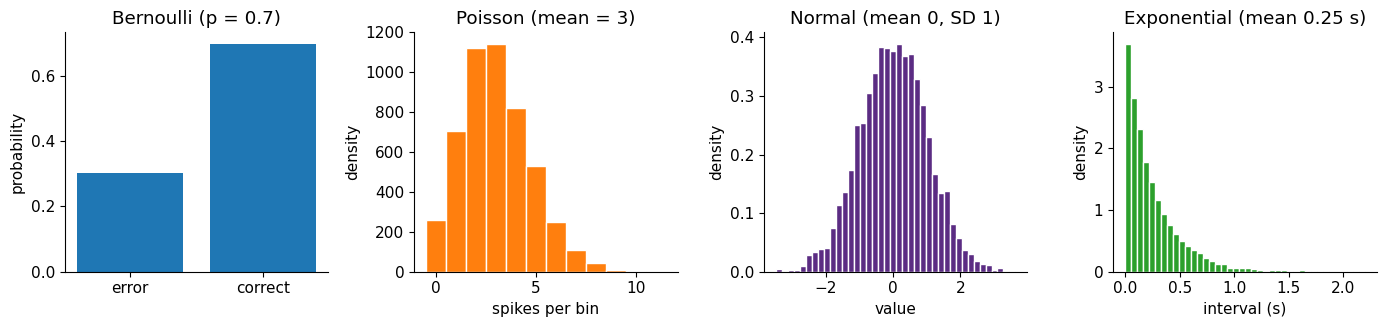

Bernoulli: 0.699 correct (asked for 0.700)
Poisson  : mean 3.02, variance 3.00  (for a Poisson these two are equal in theory)


In [6]:
# --- Draw from each of the four and plot what came out
rng = np.random.default_rng(0)
n = 5000

bernoulli = rng.random(n) < 0.7                 # a 70%-correct mouse, one trial at a time
poisson = rng.poisson(lam=3.0, size=n)          # spikes per bin, average 3
normal = rng.normal(loc=0.0, scale=1.0, size=n)
exponential = rng.exponential(scale=0.25, size=n)   # mean interval 250 ms

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))

axes[0].bar([0, 1], [np.mean(~bernoulli), np.mean(bernoulli)], color="#1f77b4")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["error", "correct"])
axes[0].set_ylabel("probability")
axes[0].set_title("Bernoulli (p = 0.7)")

axes[1].hist(poisson, bins=np.arange(-0.5, 12.5), color="#ff7f0e", edgecolor="white")
axes[1].set_xlabel("spikes per bin")
axes[1].set_title("Poisson (mean = 3)")

axes[2].hist(normal, bins=40, density=True, color="#5b2c83", edgecolor="white")
axes[2].set_xlabel("value")
axes[2].set_title("Normal (mean 0, SD 1)")

axes[3].hist(exponential, bins=40, density=True, color="#2ca02c", edgecolor="white")
axes[3].set_xlabel("interval (s)")
axes[3].set_title("Exponential (mean 0.25 s)")

for ax in axes[1:]:
    ax.set_ylabel("density")
fig.tight_layout()
plt.show()

print(f"Bernoulli: {bernoulli.mean():.3f} correct (asked for 0.700)")
print(f"Poisson  : mean {poisson.mean():.2f}, variance {poisson.var():.2f}  "
      "(for a Poisson these two are equal in theory)")

<a id="section-1-4"></a>
## 1.4 Four views of one distribution

Now the real data. The variable we will use throughout is `reaction_time_s`, the time from the
appearance of the stimulus to the first movement of the wheel.

**This column is shipped raw, on purpose.** It is computed as `first_movement_time - stimulus_on_time`
and nothing has been cleaned out of it, so it contains values that are not reaction times at all:
negative ones, where the mouse was already moving the wheel when the stimulus appeared, and
implausibly short ones, faster than a mouse can possibly see and react. IBL's own analyses treat
**0.08 s to 2 s** as the valid window. Look at the mess before you clean it: knowing what your
raw data look like is part of the job.

n              : 694,182
missing        : 30,761
negative       : 45,130
under 0.08 s   : 169,095
over 2 s       : 109,237
min / max      : -22.29 s / 60.0 s


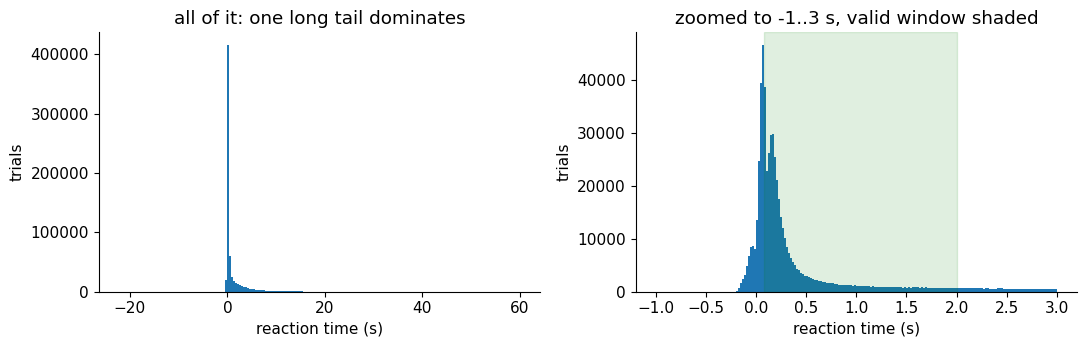

In [7]:
# --- The raw reaction times, in all their glory
rt_raw = trials["reaction_time_s"]

print(f"n              : {len(rt_raw):,}")
print(f"missing        : {rt_raw.isna().sum():,}")
print(f"negative       : {(rt_raw < 0).sum():,}")
print(f"under 0.08 s   : {(rt_raw < 0.08).sum():,}")
print(f"over 2 s       : {(rt_raw > 2).sum():,}")
print(f"min / max      : {rt_raw.min():.2f} s / {rt_raw.max():.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(rt_raw.dropna(), bins=200, color="#1f77b4")
axes[0].set_title("all of it: one long tail dominates")
axes[1].hist(rt_raw.dropna(), bins=200, range=(-1, 3), color="#1f77b4")
axes[1].axvspan(0.08, 2.0, color="green", alpha=0.12)
axes[1].set_title("zoomed to -1..3 s, valid window shaded")
for ax in axes:
    ax.set_xlabel("reaction time (s)"); ax.set_ylabel("trials")
fig.tight_layout()
plt.show()

Now the same variable, cleaned, drawn four ways. Each view answers a different question and
hides something the others show:

- the **histogram** shows the shape, but the shape depends on your choice of bin width;
- the **KDE** smooths that away, at the price of inventing a little density where there is none;
- the **box plot** is a five-number summary (median, quartiles, whiskers) and is compact enough
  to compare many groups, but it can hide a double peak completely;
- the **violin** is a KDE mirrored around the axis, so it shows the shape and compares groups,
  at the price of a busier figure.

kept 385,089 of 694,182 trials (55.5%)
discarded 309,093: missing, too fast to be a real response, or slower than 2 s


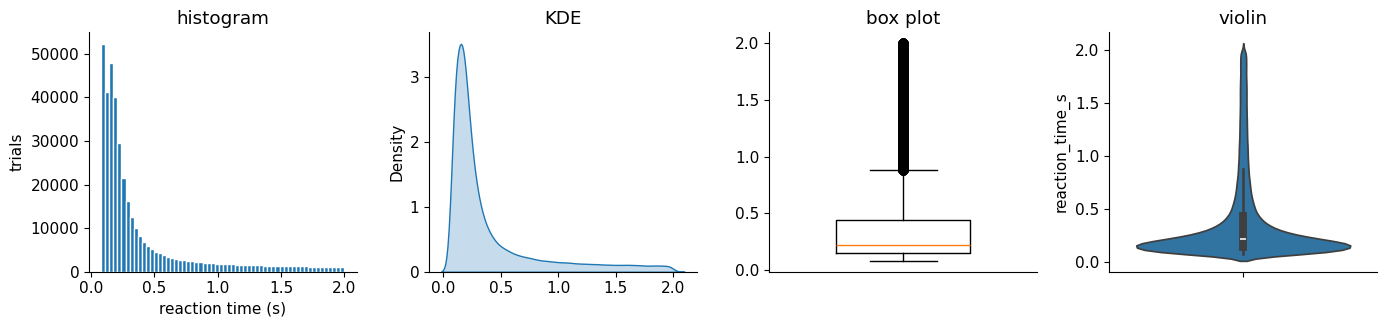

In [8]:
# --- One variable, four views
valid = trials["reaction_time_s"].between(0.08, 2.0)
rt = trials.loc[valid, "reaction_time_s"]
print(f"kept {valid.sum():,} of {len(trials):,} trials ({100 * valid.mean():.1f}%)")
print(f"discarded {(~valid).sum():,}: missing, too fast to be a real response, "
      "or slower than 2 s")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))

axes[0].hist(rt, bins=60, color="#1f77b4", edgecolor="white")
axes[0].set_title("histogram")
axes[0].set_ylabel("trials")

sns.kdeplot(x=rt, ax=axes[1], fill=True, color="#1f77b4")
axes[1].set_title("KDE")

axes[2].boxplot(rt, vert=True, widths=0.5)
axes[2].set_xticks([])
axes[2].set_title("box plot")

sns.violinplot(y=rt, ax=axes[3], color="#1f77b4")
axes[3].set_title("violin")

for ax in axes:
    ax.set_xlabel("")
axes[0].set_xlabel("reaction time (s)")
fig.tight_layout()
plt.show()

<a id="section-1-5"></a>
## 1.5 Centre and spread

Two questions about any distribution: where is it, and how wide is it. Two families of answer.

The **mean** and the **standard deviation** use every value, which makes them efficient and also
fragile: one absurd value drags them both. The **median** and the **interquartile range** (the
distance from the 25th to the 75th percentile) depend only on the ordering, so they barely move
when a few values go wild. That robustness is why they are the right default for reaction times,
which are always skewed to the right.

Below we compute both by hand with NumPy and then let pandas do it, partly to show that
`describe` is not magic.

In [9]:
# --- By hand, then with pandas
x = rt.to_numpy()

mean = x.sum() / x.size
variance = ((x - mean) ** 2).sum() / (x.size - 1)      # n-1: the sample variance
sd = np.sqrt(variance)
median = np.median(x)
q25, q75 = np.percentile(x, [25, 75])

print("by hand")
print(f"  mean {mean:.3f} s | SD {sd:.3f} s | median {median:.3f} s | IQR {q75 - q25:.3f} s")
print("\nwith pandas")
print(rt.describe().round(3).to_string())

by hand
  mean 0.402 s | SD 0.430 s | median 0.219 s | IQR 0.295 s

with pandas
count    385089.000
mean          0.402
std           0.430
min           0.080
25%           0.146
50%           0.219
75%           0.441
max           2.000


Notice that the mean sits above the median. That gap is the signature of a **right-skewed**
distribution: a long tail of slow trials pulls the mean up while leaving the median where it is.
Whenever you see mean and median disagree, plot the thing before you summarise it.

> **▶ Task 1.1 ⭐ - Read a summary table, and clean a variable.**
> The column `response_time_s` is the *other* latency in the dataset: the time from the stimulus
> to the moment the mouse finished its movement, rather than started it.
> 1. Print `describe()` for the raw `response_time_s`.
> 2. Count how many values are negative, and how many are above 10 s.
> 3. Apply a sensible validity window of your own choosing, say it out loud in a comment, and
>    print `describe()` again.
> 4. In a comment: does the mean or the median move more when you clean it, and why?

In [10]:
# TODO 1.1 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
resp = trials["response_time_s"]
print("RAW")
print(resp.describe().round(3).to_string())
print(f"\nnegative      : {(resp < 0).sum():,}")
print(f"above 10 s    : {(resp > 10).sum():,}")

# A response time must be positive, and cannot be longer than the 60 s response window.
# We keep 0.08 s (the same physiological floor as the reaction time) to 10 s.
resp_clean = resp[resp.between(0.08, 10.0)]
print("\nCLEANED to 0.08-10 s")
print(resp_clean.describe().round(3).to_string())
print(f"\nmean moved by   {resp.mean() - resp_clean.mean():+.3f} s")
print(f"median moved by {resp.median() - resp_clean.median():+.3f} s")
# The mean moves far more. It is computed from every value, so the handful of enormous ones
# drag it; the median only cares about which value sits in the middle, and throwing away
# extremes barely changes that.
# --- END SOLUTION

RAW
count    681969.000
mean          2.247
std           5.511
min          -1.949
25%           0.306
50%           0.500
75%           1.702
max          60.100

negative      : 106
above 10 s    : 31,086

CLEANED to 0.08-10 s
count    650223.000
mean          1.303
std           1.843
min           0.080
25%           0.301
50%           0.473
75%           1.309
max          10.000

mean moved by   +0.944 s
median moved by +0.027 s


<a id="section-2"></a>
# Part 2. From a sample to an estimate

Part 1 described the data in front of us. Now the harder question: what does it tell us about
the process that produced it, and how sure can we be?

<a id="section-2-1"></a>
## 2.1 Expectation and variance

For a random variable, the **expectation** E[X] is the long-run average value, and the
**variance** Var[X] is the long-run average squared distance from it. These are properties of
the *process*, not of any sample. What we compute from data are **estimates** of them, and the
estimates get better as the sample grows. Below, a distribution whose true values we know.

In [11]:
# --- Sample estimates approach the true values
rng = np.random.default_rng(1)
true_mean, true_sd = 0.35, 0.12          # a made-up reaction time, in seconds

for n in [10, 100, 1000, 100_000]:
    sample = rng.normal(true_mean, true_sd, size=n)
    print(f"n = {n:>6,}: mean {sample.mean():.4f}  SD {sample.std(ddof=1):.4f}")
print(f"{'truth':>10}: mean {true_mean:.4f}  SD {true_sd:.4f}")

n =     10: mean 0.3770  SD 0.0796
n =    100: mean 0.3404  SD 0.1061
n =  1,000: mean 0.3428  SD 0.1203
n = 100,000: mean 0.3496  SD 0.1197
     truth: mean 0.3500  SD 0.1200


<a id="section-2-2"></a>
## 2.2 The sampling distribution of the mean

Here is the central simulation of the notebook. We treat the cleaned reaction times as a
population, draw a **sample of 20 trials** from it, and compute the mean. Then we do it again.
And again, two thousand times. The histogram of those two thousand means is the **sampling
distribution of the mean**: it shows what "the mean of 20 trials" does across repetitions of the
same experiment.

Any single real experiment gives you **one** draw from that histogram. You never see the
histogram itself. The point of statistics is to reason about it anyway.

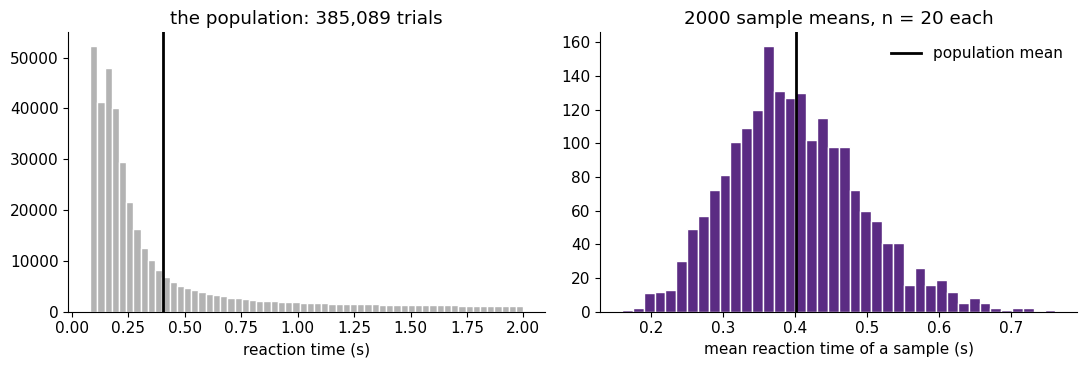

population mean      : 0.4020 s
mean of sample means : 0.3999 s
SD of sample means   : 0.0915 s   <- this is the standard error


In [12]:
# --- Build a sampling distribution by brute force
rng = np.random.default_rng(3)
population = rt.to_numpy()          # our stand-in for "all possible trials"

n_per_sample = 20
n_repeats = 2000
sample_means = np.array([rng.choice(population, size=n_per_sample).mean()
                         for _ in range(n_repeats)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(population, bins=60, color="0.7", edgecolor="white")
axes[0].axvline(population.mean(), color="black", lw=2)
axes[0].set_title(f"the population: {len(population):,} trials")
axes[0].set_xlabel("reaction time (s)")

axes[1].hist(sample_means, bins=40, color="#5b2c83", edgecolor="white")
axes[1].axvline(population.mean(), color="black", lw=2, label="population mean")
axes[1].set_title(f"{n_repeats} sample means, n = {n_per_sample} each")
axes[1].set_xlabel("mean reaction time of a sample (s)")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"population mean      : {population.mean():.4f} s")
print(f"mean of sample means : {sample_means.mean():.4f} s")
print(f"SD of sample means   : {sample_means.std(ddof=1):.4f} s   <- this is the standard error")

Two things to take from that figure. The sampling distribution is **centred** on the population
mean, which says the sample mean is an unbiased estimator. And it is **much narrower** than the
population, because averaging cancels out some of the noise. How much narrower is the subject of
the next two sections.

<a id="section-2-3"></a>
## 2.3 The Law of Large Numbers

The LLN says the sample mean converges to the expectation as the sample grows. Not "gets close
and stays there by luck", but converges: the wobble shrinks without limit. The clearest way to
see it is to add observations one at a time and watch the running mean settle.

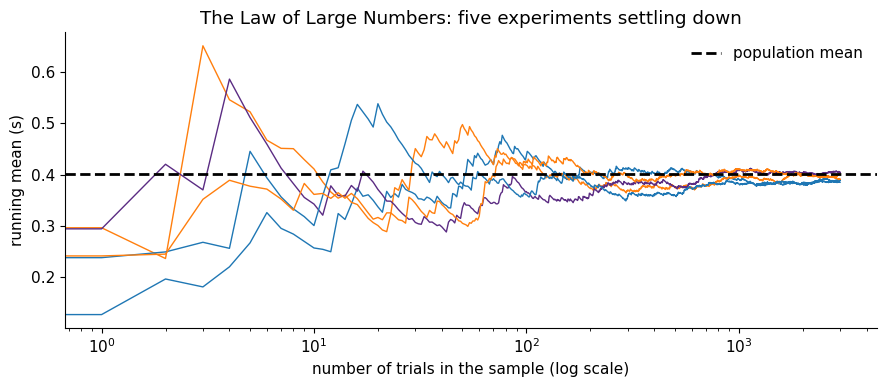

In [13]:
# --- Running mean of a growing sample, five independent repetitions
rng = np.random.default_rng(5)

fig, ax = plt.subplots(figsize=(9, 4))
for repeat in range(5):
    draws = rng.choice(population, size=3000)
    running = np.cumsum(draws) / np.arange(1, draws.size + 1)
    ax.plot(running, lw=1)

ax.axhline(population.mean(), color="black", lw=2, ls="--", label="population mean")
ax.set_xscale("log")
ax.set_xlabel("number of trials in the sample (log scale)")
ax.set_ylabel("running mean (s)")
ax.set_title("The Law of Large Numbers: five experiments settling down")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

<a id="section-2-4"></a>
## 2.4 The Central Limit Theorem

The LLN says where the sample mean ends up. The CLT says what its **shape** is on the way there,
and the answer is remarkable: whatever the population looks like, the distribution of the sample
mean tends to a **Normal** distribution as n grows.

That is worth pausing on here, because our population is visibly *not* Normal: reaction times
are skewed hard to the right. Watch what happens to the sampling distribution as n increases.

The CLT also tells us the width. The standard deviation of the sampling distribution, called the
**standard error of the mean**, is

$$\text{SEM} \;=\; \frac{\text{SD}}{\sqrt{n}}$$

so quadrupling your sample halves your uncertainty. The square root is why large studies get
expensive.

n =   2: observed SD of means 0.2966, predicted SD/sqrt(n) 0.3037
n =  10: observed SD of means 0.1353, predicted SD/sqrt(n) 0.1358
n = 100: observed SD of means 0.0432, predicted SD/sqrt(n) 0.0430


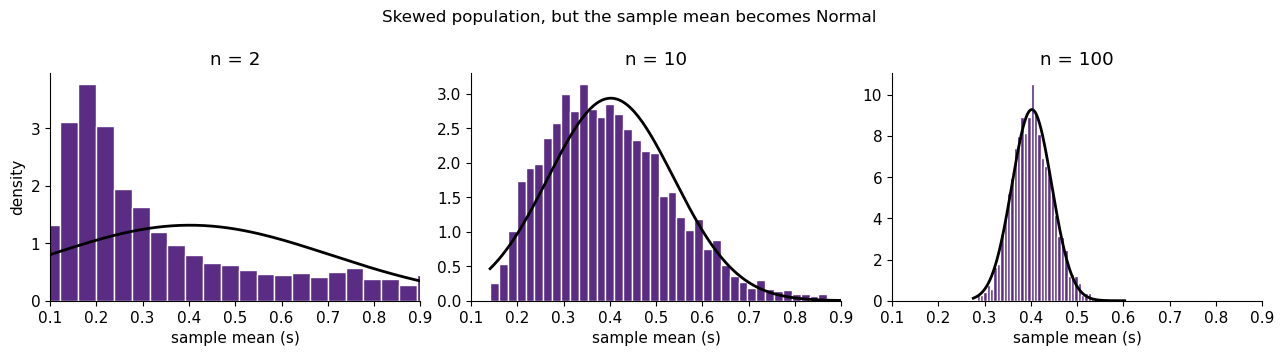

In [14]:
# --- The sampling distribution for three sample sizes, with the predicted SEM
rng = np.random.default_rng(8)
sizes = [2, 10, 100]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, n in zip(axes, sizes):
    means = np.array([rng.choice(population, size=n).mean() for _ in range(3000)])
    ax.hist(means, bins=45, density=True, color="#5b2c83", edgecolor="white")

    # the Normal the CLT predicts
    grid = np.linspace(means.min(), means.max(), 200)
    predicted_sem = population.std(ddof=1) / np.sqrt(n)
    normal_pdf = np.exp(-0.5 * ((grid - population.mean()) / predicted_sem) ** 2) / (
        predicted_sem * np.sqrt(2 * np.pi))
    ax.plot(grid, normal_pdf, color="black", lw=2)

    ax.set_title(f"n = {n}")
    ax.set_xlabel("sample mean (s)")
    print(f"n = {n:>3}: observed SD of means {means.std(ddof=1):.4f}, "
          f"predicted SD/sqrt(n) {predicted_sem:.4f}")

axes[0].set_ylabel("density")
axes[0].set_xlim(0.1, 0.9)
fig.suptitle("Skewed population, but the sample mean becomes Normal", fontsize=12)
fig.tight_layout()
plt.show()

At n = 2 the histogram is still visibly lopsided, inherited from the population. By n = 10 it is
close to the black curve, and by n = 100 the two are hard to tell apart. The observed width
matches SD/sqrt(n) at every step.

<a id="section-2-5"></a>
## 2.5 SD versus SEM

This is the most consequential distinction in the notebook, and the most common mistake in
published figures.

- The **SD** describes the **data**: how much individual observations differ from each other. It
  does not shrink when you collect more data, because it is a property of the population.
- The **SEM** describes your **estimate**: how much the mean would move if you ran the experiment
  again. It shrinks as sqrt(n).

Both are drawn as error bars and they look identical on paper, which is why every figure caption
must say which one it is. If you want to say "these mice are variable", show the SD. If you want
to say "I know where the average is", show the SEM.

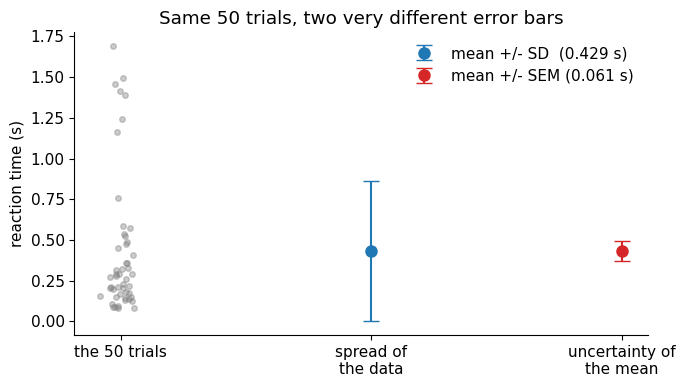

SD  = 0.4291 s   (would not shrink with more trials)
SEM = 0.0607 s   (would halve if we collected 4x as many)


In [15]:
# --- The same data, two error bars, two different claims
rng = np.random.default_rng(13)
sample = rng.choice(population, size=50)

sd = sample.std(ddof=1)
sem = sd / np.sqrt(sample.size)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.full(sample.size, 0) + rng.normal(0, 0.03, sample.size), sample,
        "o", ms=4, alpha=0.4, color="0.5")
ax.errorbar([1], [sample.mean()], yerr=[sd], fmt="o", capsize=6, ms=8,
            color="#1f77b4", label=f"mean +/- SD  ({sd:.3f} s)")
ax.errorbar([2], [sample.mean()], yerr=[sem], fmt="o", capsize=6, ms=8,
            color="#d62728", label=f"mean +/- SEM ({sem:.3f} s)")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["the 50 trials", "spread of\nthe data", "uncertainty of\nthe mean"])
ax.set_ylabel("reaction time (s)")
ax.set_title("Same 50 trials, two very different error bars")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"SD  = {sd:.4f} s   (would not shrink with more trials)")
print(f"SEM = {sem:.4f} s   (would halve if we collected 4x as many)")

> **▶ Task 2.1 ⭐⭐ - Complete the sampling-distribution loop.**
> Write a function `sampling_distribution(population, n, repeats, rng)` that returns an array of
> `repeats` sample means, each computed from `n` values drawn from `population`. Then use it to
> check the sqrt(n) law directly: for n in 5, 20, 80, 320, compute the SD of the sample means and
> print it next to `population.std(ddof=1) / np.sqrt(n)`.
>
> Each time n is multiplied by 4, what happens to the standard error?

In [16]:
# TODO 2.1 - your code here
# def sampling_distribution(population, n, repeats, rng):
#     ...

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def sampling_distribution(population, n, repeats, rng):
    """Return `repeats` means of samples of size n drawn from population."""
    return np.array([rng.choice(population, size=n).mean() for _ in range(repeats)])

rng = np.random.default_rng(21)
print(f"{'n':>5} {'observed':>10} {'SD/sqrt(n)':>12}")
for n in [5, 20, 80, 320]:
    means = sampling_distribution(population, n, 2000, rng)
    print(f"{n:>5} {means.std(ddof=1):>10.4f} "
          f"{population.std(ddof=1) / np.sqrt(n):>12.4f}")
# Every fourfold increase in n halves the standard error, because sqrt(4) = 2.
# --- END SOLUTION

    n   observed   SD/sqrt(n)
    5     0.1960       0.1921
   20     0.0921       0.0961
   80     0.0476       0.0480
  320     0.0246       0.0240


> **▶ Task 2.2 ⭐⭐ - Standardise a value.**
> The **z-score** of an observation says how many standard deviations it sits from the mean:
> $z = (x - \mu)/\sigma$. It is how you compare things measured on different scales.
> 1. Compute the z-score of a 1.2 s reaction time with respect to the cleaned population.
> 2. Compute the z-score of a *sample mean* of 1.2 s from 20 trials, this time using the SEM
>    rather than the SD as the denominator.
> 3. The two answers are wildly different. Explain in a comment which question each one answers.

In [17]:
# TODO 2.2 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
mu = population.mean()
sigma = population.std(ddof=1)
sem20 = sigma / np.sqrt(20)

z_single = (1.2 - mu) / sigma
z_mean = (1.2 - mu) / sem20

print(f"population mean {mu:.3f} s, SD {sigma:.3f} s, SEM for n=20 {sem20:.3f} s")
print(f"z of a single 1.2 s trial      : {z_single:.2f}")
print(f"z of a 1.2 s mean over 20 trials: {z_mean:.2f}")
# The first asks "is this trial unusual for a mouse?", and the answer is only mildly: slow
# trials like this happen often. The second asks "could a whole 20-trial average land here by
# chance?", and the answer is essentially never, because averages barely move. Same number,
# two completely different questions, and the denominator is what distinguishes them.
# --- END SOLUTION

population mean 0.402 s, SD 0.430 s, SEM for n=20 0.096 s
z of a single 1.2 s trial      : 1.86
z of a 1.2 s mean over 20 trials: 8.31


<a id="section-3"></a>
# Part 3. Describing the real data

Everything so far has been a warm-up for this: describing thirty real mice honestly. Note what
we will *not* do this week. We will not compute a p-value or claim that any difference is
significant. We will describe what is there, look at how variable it is, and set up the question
that Notebook 4 answers.

<a id="section-3-1"></a>
## 3.1 Reaction times by cohort

The first real grouping. `groupby` is the pandas verb for "split the table by this column,
compute something in each piece, and put the answers back together".

In [18]:
# --- Summary table of cleaned reaction times, per cohort
clean = trials[trials["reaction_time_s"].between(0.08, 2.0)]

summary = (clean.groupby("cohort")["reaction_time_s"]
                .agg(n="size", mean="mean", median="median", sd="std",
                     q25=lambda s: s.quantile(0.25),
                     q75=lambda s: s.quantile(0.75))
                .reindex(COHORT_ORDER))
summary["IQR"] = summary["q75"] - summary["q25"]
print(summary.round(3).to_string())

              n   mean  median     sd    q25    q75    IQR
cohort                                                    
CSHL-WT  112388  0.389   0.185  0.455  0.105  0.432  0.327
NYU-WT   119540  0.422   0.235  0.431  0.165  0.461  0.296
CSP-ASD  153161  0.396   0.226  0.408  0.155  0.433  0.278


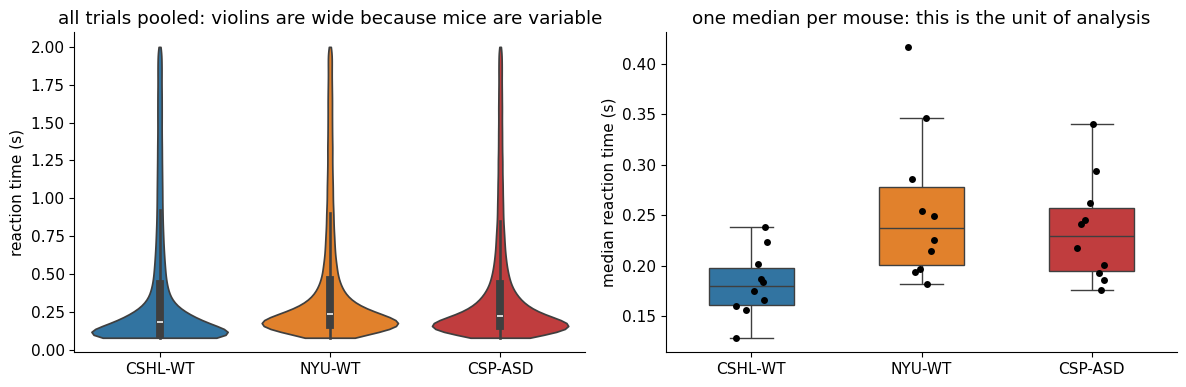

In [19]:
# --- The same three groups, drawn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.violinplot(data=clean, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
               hue="cohort", palette=COHORT_COLOR, legend=False, ax=axes[0], cut=0)
axes[0].set_title("all trials pooled: violins are wide because mice are variable")
axes[0].set_ylabel("reaction time (s)")

# One point per mouse instead of one per trial: 30 numbers, not 600,000.
per_mouse = (clean.groupby(["cohort", "subject_id"])["reaction_time_s"]
                  .median().reset_index())
sns.boxplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
            hue="cohort", palette=COHORT_COLOR, legend=False, ax=axes[1],
            width=0.5, fliersize=0)
sns.stripplot(data=per_mouse, x="cohort", y="reaction_time_s", order=COHORT_ORDER,
              color="black", size=5, ax=axes[1])
axes[1].set_title("one median per mouse: this is the unit of analysis")
axes[1].set_ylabel("median reaction time (s)")

for ax in axes:
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

The two panels contain the same data and answer different questions, and the difference matters
enormously for next week.

On the left, every trial is a point, so n is in the hundreds of thousands. On the right, each
mouse contributes **one** number, so n is 30. Trials from the same mouse are not independent of
each other: they share an animal, a training history, a cage. Treating 600,000 correlated trials
as 600,000 independent observations would make any test wildly overconfident, which is a mistake
common enough to have a name, **pseudoreplication**. The per-mouse panel is the honest unit, and
it is the one Notebook 4 will run its tests on.

Reaction times are right-skewed, which we saw in Part 1. A standard move is to describe them on
a **logarithmic** scale, where the distribution becomes much more symmetric and the mean and
median move back together. This is the log from Notebook 2, doing real work.

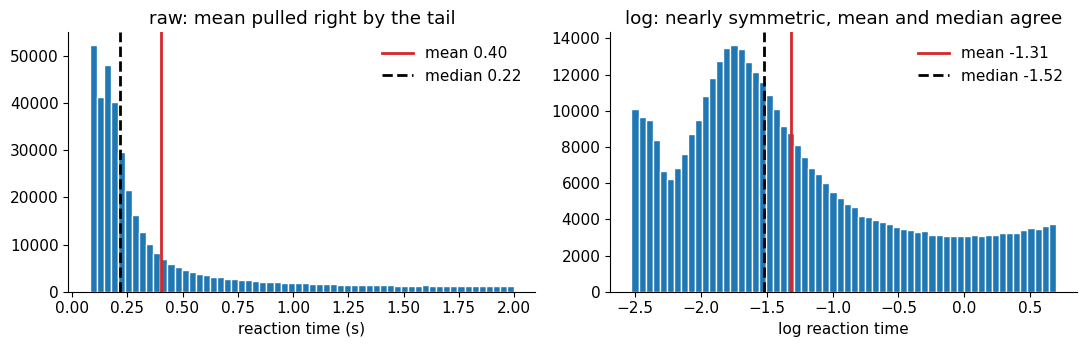

In [20]:
# --- Raw versus log reaction times
log_rt = np.log(clean["reaction_time_s"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, values, name in [(axes[0], clean["reaction_time_s"], "reaction time (s)"),
                         (axes[1], log_rt, "log reaction time")]:
    ax.hist(values, bins=60, color="#1f77b4", edgecolor="white")
    ax.axvline(values.mean(), color="#d62728", lw=2, label=f"mean {values.mean():.2f}")
    ax.axvline(values.median(), color="black", lw=2, ls="--",
               label=f"median {values.median():.2f}")
    ax.set_xlabel(name); ax.legend(frameon=False)
axes[0].set_title("raw: mean pulled right by the tail")
axes[1].set_title("log: nearly symmetric, mean and median agree")
fig.tight_layout()
plt.show()

<a id="section-3-2"></a>
## 3.2 Learning curves

The `training` phase holds each mouse's complete history on the basic task, from its first
session to the day it graduated. Averaging accuracy within each session gives a **learning
curve**, and it has the shape Notebook 2 spent time on: a rise towards an asymptote.

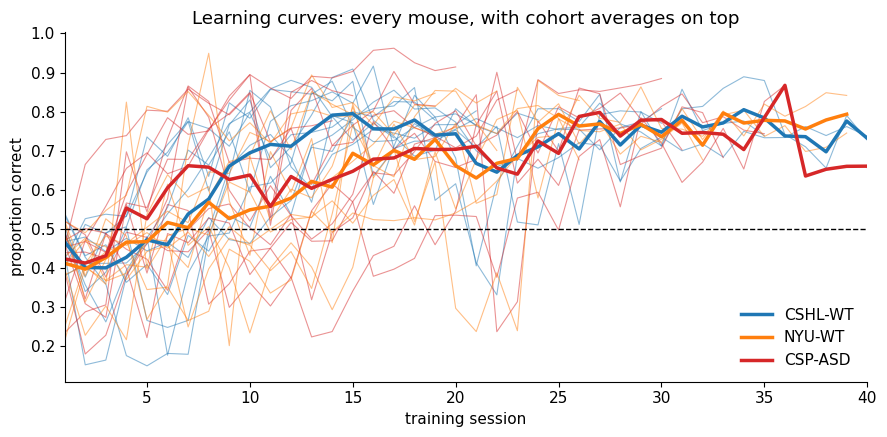

sessions per mouse: 14 to 64, median 25


In [21]:
# --- One learning curve per mouse, coloured by cohort
training = trials[trials["phase"] == "training"]
curve = (training.groupby(["cohort", "subject_id", "session"])["correct"]
                 .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4.5))
for (cohort, mouse), piece in curve.groupby(["cohort", "subject_id"]):
    ax.plot(piece["session"], piece["correct"], lw=0.8, alpha=0.5,
            color=COHORT_COLOR[cohort])

# the cohort averages on top, session by session
for cohort in COHORT_ORDER:
    avg = curve[curve["cohort"] == cohort].groupby("session")["correct"].mean()
    ax.plot(avg.index, avg.values, lw=2.5, color=COHORT_COLOR[cohort], label=cohort)

ax.axhline(0.5, color="black", lw=1, ls="--")
ax.set_xlabel("training session")
ax.set_ylabel("proportion correct")
ax.set_title("Learning curves: every mouse, with cohort averages on top")
ax.set_xlim(1, 40)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

n_sessions = training.groupby("subject_id")["session"].max()
print(f"sessions per mouse: {n_sessions.min()} to {n_sessions.max()}, "
      f"median {n_sessions.median():.0f}")

Two honest observations about that figure. The individual curves are noisy and the mice differ a
lot from each other, which is what real learning data look like. And the cohort averages become
unreliable at the right-hand edge, because only the slowest learners are still in the training
phase by then: the average at session 40 is computed over a handful of animals, not thirty. That
is **survivorship** creeping into a group average, and it is the kind of thing you catch by
plotting the individuals rather than only the mean.

<a id="section-3-3"></a>
## 3.3 Psychometric curves

The psychometric curve is the summary of a perceptual experiment: the probability of choosing
"right" as a function of the signed contrast. This is the sigmoid from Notebook 2, now measured
rather than invented. Its **midpoint** is the contrast at which the mouse is indifferent, and its
**steepness** says how sharply it discriminates.

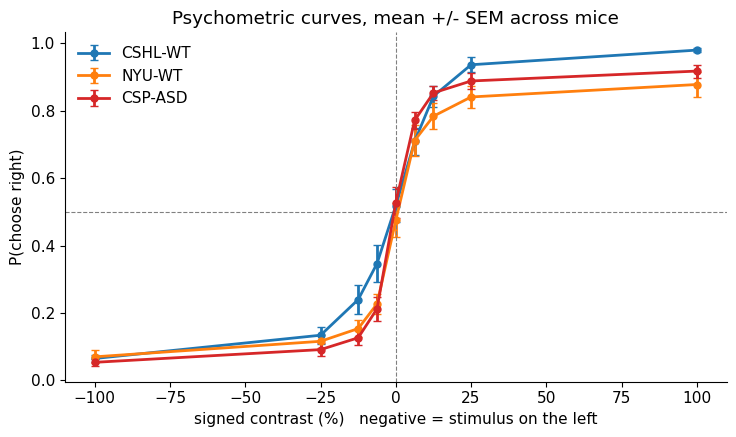

In [22]:
# --- Psychometric curve per cohort, from the trained phase
trained = trials[(trials["phase"] == "trained") & (~trials["no_go"])]

# P(choose right) for each contrast, computed per mouse and then averaged per cohort
per_mouse_psy = (trained.groupby(["cohort", "subject_id", "signed_contrast"])["response"]
                        .mean().reset_index())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for cohort in COHORT_ORDER:
    piece = per_mouse_psy[per_mouse_psy["cohort"] == cohort]
    avg = piece.groupby("signed_contrast")["response"].agg(["mean", "sem"])
    ax.errorbar(avg.index * 100, avg["mean"], yerr=avg["sem"], marker="o", ms=5,
                lw=2, capsize=3, color=COHORT_COLOR[cohort], label=cohort)

ax.axhline(0.5, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("signed contrast (%)   negative = stimulus on the left")
ax.set_ylabel("P(choose right)")
ax.set_title("Psychometric curves, mean +/- SEM across mice")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Note the error bars: they are SEMs computed **across mice**, so the n behind them is 10 per
cohort, not the number of trials. That is the same choice as in section 3.1, and it is the
choice that keeps the figure honest.

<a id="section-3-4"></a>
## 3.4 Re-running the experiment: sessions as samples

In Part 2 we built a sampling distribution by simulation, drawing imaginary repetitions from a
population. Real data lets us do something better: each **session** of a mouse is a genuine
repetition of the same experiment on the same animal. So the spread of a mouse's per-session
accuracy is a sampling distribution we did not have to invent.

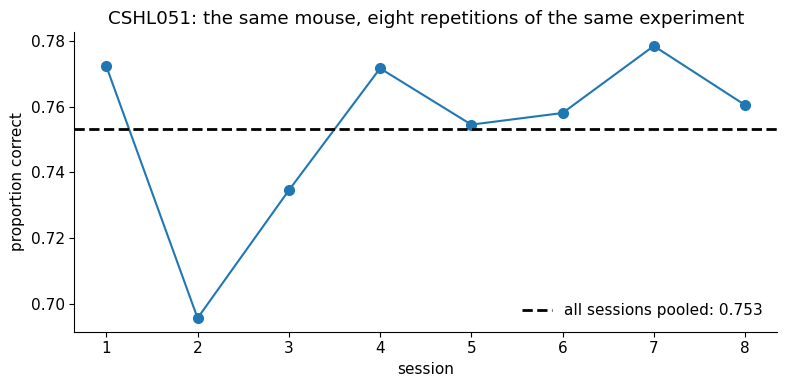

          mean  size
session             
1        0.772  1133
2        0.696   644
3        0.735   825
4        0.772   692
5        0.755   770
6        0.758   835
7        0.778   465
8        0.761   238

spread across sessions: SD 0.0270, SEM 0.0095


In [23]:
# --- One mouse, eight sessions: the estimate wobbles
example_mouse = trained["subject_id"].iloc[0]
one = trained[trained["subject_id"] == example_mouse]

by_session = one.groupby("session")["correct"].agg(["mean", "size"])
overall = one["correct"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_session.index, by_session["mean"], "o-", ms=7, color="#1f77b4")
ax.axhline(overall, color="black", lw=2, ls="--",
           label=f"all sessions pooled: {overall:.3f}")
ax.set_xlabel("session")
ax.set_ylabel("proportion correct")
ax.set_title(f"{example_mouse}: the same mouse, eight repetitions of the same experiment")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(by_session.round(3).to_string())
print(f"\nspread across sessions: SD {by_session['mean'].std(ddof=1):.4f}, "
      f"SEM {by_session['mean'].std(ddof=1) / np.sqrt(len(by_session)):.4f}")

<a id="section-3-5"></a>
## 3.5 A group difference, described

Finally, the comparison the dataset was built for.

In the `trained` phase the task has a twist. The stimulus is not equally likely on both sides:
the experiment runs in **blocks**, and inside a block the probability that the stimulus appears
on the left is either 0.2 or 0.8. The mouse is never told when a block changes, but a good
learner picks it up and starts leaning towards the more likely side. That leaning shows up most
clearly on the **zero-contrast** trials, where there is nothing at all to see and the prior is
the only thing left to go on.

So each mouse gives us one number: how far its choices shift between the two block types at zero
contrast. Call it the **prior-updating shift**. A mouse that ignores the block structure has a
shift near zero, a mouse that exploits it fully has a large one.

Within the Angelaki lab there are ten wild-type mice (`NYU-WT`) and ten carrying the Cntnap2
mutation (`CSP-ASD`), so a difference between those two is not confounded by the lab, the rig or
the protocol. This is the measurement where they are expected to differ, and it is the one
Notebook 4 will test. Here we only look at it.

We describe the difference and stop there. No test, no p-value: those are next week. What we
*can* do is express it in a way that does not depend on the units, by dividing by the spread of
the data:

$$d \;=\; \frac{\bar{x}_A - \bar{x}_B}{s_{\text{pooled}}}$$

Read that as "the groups differ by d standard deviations". Note carefully what sits in the
denominator: the **standard deviation across mice**, not the standard error. It answers "how big
is this difference compared with how much mice vary", which is a question about biology.
Dividing by the SEM instead would answer "how surprising is this difference", which is a question
about our certainty, and that is exactly the step Notebook 4 takes.

In [24]:
# --- The per-mouse prior-updating shift at zero contrast
zero = trained[(trained["signed_contrast"] == 0) & (trained["probability_left"] != 0.5)]

by_block = (zero.groupby(["cohort", "subject_id", "probability_left"])["response"]
                .mean().unstack("probability_left"))
by_block.columns = [f"p_right_pleft_{c}" for c in by_block.columns]
by_block["shift"] = by_block["p_right_pleft_0.2"] - by_block["p_right_pleft_0.8"]
shift = by_block.reset_index()

print(f"{len(zero):,} zero-contrast trials in biased blocks, from {len(shift)} mice\n")
print(shift.groupby("cohort")["shift"]
           .agg(n="size", mean="mean", sd="std").reindex(COHORT_ORDER).round(4).to_string())

32,376 zero-contrast trials in biased blocks, from 30 mice

          n    mean      sd
cohort                     
CSHL-WT  10  0.3902  0.1108
NYU-WT   10  0.2924  0.0752
CSP-ASD  10  0.2265  0.0530


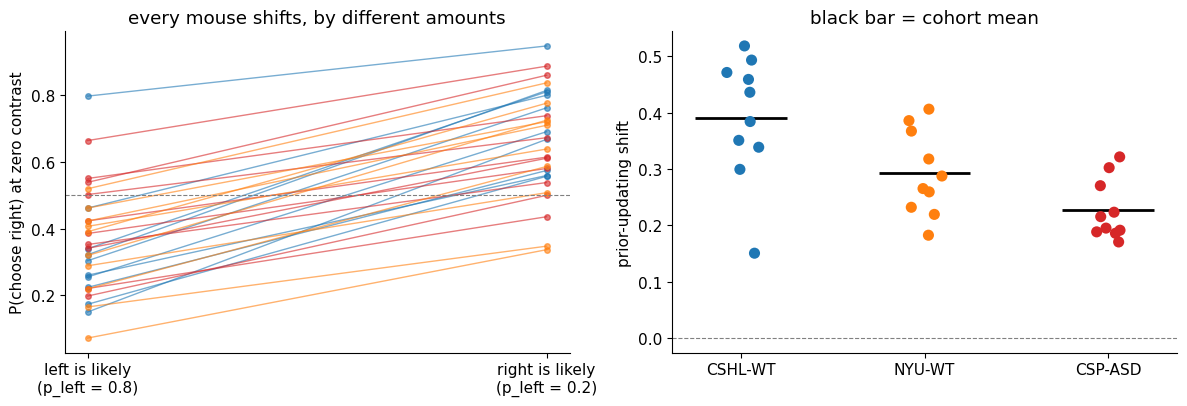

In [25]:
# --- One dot per mouse: how much each animal leans on the block prior
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# left: the choices themselves, one line per mouse, in the two block types
for _, row in shift.iterrows():
    axes[0].plot([0, 1], [row["p_right_pleft_0.8"], row["p_right_pleft_0.2"]],
                 "-o", ms=4, lw=1, alpha=0.6, color=COHORT_COLOR[row["cohort"]])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["left is likely\n(p_left = 0.8)", "right is likely\n(p_left = 0.2)"])
axes[0].set_ylabel("P(choose right) at zero contrast")
axes[0].axhline(0.5, color="gray", lw=0.8, ls="--")
axes[0].set_title("every mouse shifts, by different amounts")

# right: the shift itself, one number per mouse
sns.stripplot(data=shift, x="cohort", y="shift", order=COHORT_ORDER, hue="cohort",
              palette=COHORT_COLOR, legend=False, size=8, ax=axes[1])
for i, cohort in enumerate(COHORT_ORDER):
    values = shift.loc[shift["cohort"] == cohort, "shift"]
    axes[1].hlines(values.mean(), i - 0.25, i + 0.25, color="black", lw=2)
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_xlabel(""); axes[1].set_ylabel("prior-updating shift")
axes[1].set_title("black bar = cohort mean")

fig.tight_layout()
plt.show()

> **▶ Task 3.1 ⭐⭐⭐ - Describe the difference, standardised.**
> Using the `shift` table from above:
> 1. Write a function `standardised_difference(a, b)` that takes two arrays of per-mouse values
>    and returns their difference in units of the **pooled standard deviation**,
>    $s_{\text{pooled}} = \sqrt{\tfrac{1}{2}(s_A^2 + s_B^2)}$ for two groups of equal size.
> 2. Apply it to the lab-matched genotype comparison, `NYU-WT` against `CSP-ASD`.
> 3. Apply it to the lab comparison between the two wild-type cohorts, `CSHL-WT` against `NYU-WT`.
> 4. Now compute the same two differences divided by the **standard error** instead of the
>    standard deviation, and put all four numbers in one small table.
> 5. In a comment: which pair of numbers tells you the effect is *large*, and which tells you it
>    would be *hard to explain by chance*? Why are they not the same question?

In [26]:
# TODO 3.1 - your code here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def standardised_difference(a, b):
    """Difference between two groups, in units of their pooled standard deviation."""
    pooled_sd = np.sqrt(0.5 * (np.var(a, ddof=1) + np.var(b, ddof=1)))
    return (np.mean(a) - np.mean(b)) / pooled_sd

def difference_in_sem(a, b):
    """The same difference, in units of the standard error instead."""
    pooled_sd = np.sqrt(0.5 * (np.var(a, ddof=1) + np.var(b, ddof=1)))
    sem = pooled_sd * np.sqrt(1 / len(a) + 1 / len(b))
    return (np.mean(a) - np.mean(b)) / sem

groups = {c: shift.loc[shift["cohort"] == c, "shift"].to_numpy() for c in COHORT_ORDER}

rows = []
for label, (a, b) in {"genotype (NYU-WT vs CSP-ASD)": ("NYU-WT", "CSP-ASD"),
                      "lab (CSHL-WT vs NYU-WT)": ("CSHL-WT", "NYU-WT")}.items():
    rows.append({"comparison": label,
                 "raw difference": np.mean(groups[a]) - np.mean(groups[b]),
                 "in SD units": standardised_difference(groups[a], groups[b]),
                 "in SEM units": difference_in_sem(groups[a], groups[b])})
print(pd.DataFrame(rows).round(3).to_string(index=False))

# The "in SD units" column says how big the difference is compared with how much mice vary:
# that is a statement about biology, and it does not change if we test more animals. The
# "in SEM units" column says how far the observed difference sits from zero on the scale of
# our uncertainty: that is a statement about evidence, and it grows as we add mice. A tiny
# effect measured in thousands of animals scores high on the second and low on the first.
# The second column is Cohen's d and the third is essentially a t statistic, which is where
# Notebook 4 begins.
# --- END SOLUTION

                  comparison  raw difference  in SD units  in SEM units
genotype (NYU-WT vs CSP-ASD)           0.066        1.013         2.266
     lab (CSHL-WT vs NYU-WT)           0.098        1.034         2.312


<a id="section-4"></a>
# 4. What comes next

You can now take a table you have never seen, clean a variable, describe it with the right
summary for its shape, and say how much of what you see is the process and how much is the luck
of the draw.

The last task is the bridge. You computed a difference between two groups of mice twice: once
divided by the standard deviation, once by the standard error. Those two numbers are the two
halves of statistical inference:

- the first is the **effect size**, and next week it gets its proper name, Cohen's d;
- the second is a **test statistic**, and next week we work out how surprising a given value of
  it would be if there were no difference at all. That is a p-value.

Notebook 4 also returns to the three comparisons in this dataset, genotype, lab and sex, and asks
which of them survive contact with a hypothesis test. One of the three is a genuine null result,
and it is there on purpose: seeing a comparison come out flat is as instructive as seeing one
come out significant.